In [22]:
!pip install torch torchvision torchaudio
!pip install pandas numpy scikit-learn matplotlib
!pip install opencv-python mediapipe

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [23]:
# Cell 1: Imports & basic configuration

import os
import glob
import time
import math
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)




Using device: cpu


In [ ]:
# Cell 1: CSV Label Correction (Run this FIRST before training)
import os
import csv

# =========================
# CSV LABEL FIX CONFIG
# =========================
DATA_ROOT = r"C:\transformer_nikhil_demo\Nikhil_data_Transformer\data_merged_one_hand"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR  = os.path.join(DATA_ROOT, "test")
VAL_DIR   = os.path.join(DATA_ROOT, "val")     


OLD_LABEL = "Sor"
NEW_LABEL = "Sorry"

FILENAME_KEYWORD = "Saavni"   # only Saavni files
DRY_RUN = False           # set True to verify first


def fix_csv(csv_path):
    """Fix label in CSV file"""
    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        rows = list(csv.reader(f))

    if not rows:
        return False

    changed = False

    for i, row in enumerate(rows):
        if not row:
            continue

        if row[0].strip() == OLD_LABEL:
            row[0] = NEW_LABEL
            changed = True

    if changed and not DRY_RUN:
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerows(rows)

    return changed


def process_dir(directory):
    """Process all CSVs in directory"""
    fixed = 0
    for file in os.listdir(directory):
        if (
            file.lower().endswith(".csv")
            and FILENAME_KEYWORD.lower() in file.lower()
        ):
            path = os.path.join(directory, file)
            if fix_csv(path):
                print(f"✔ Fixed: {path}")
                fixed += 1
    return fixed


# Run the fix
print("🚀 Saavni CSV Label Correction Started")
print(f"🎯 {OLD_LABEL} → {NEW_LABEL}")
print(f"🧪 Dry run: {DRY_RUN}\n")

total = 0
total += process_dir(TRAIN_DIR)
total += process_dir(TEST_DIR)
total += process_dir(VAL_DIR)

print(f"\n✅ Done. Total files updated: {total}")

🚀 Saavni CSV Label Correction Started
🎯 Sor → Sorry
🧪 Dry run: False


✅ Done. Total files updated: 0


In [25]:
# Paths (ADJUST to your dataset paths)
DATA_ROOT = r"C:\transformer_nikhil_demo\Nikhil_data_Transformer\data_merged_one_hand"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR  = os.path.join(DATA_ROOT, "test")
VAL_DIR   = os.path.join(DATA_ROOT, "val")     

# Transformer hyperparameters
MAX_SEQ_LEN   = 59          # based on your info; we will truncate/pad to 59
FEATURE_DIM   = 126         # 127 cols - 1 label column
D_MODEL       = 256         # embedding dimension
N_HEAD        = 8           # number of attention heads
NUM_LAYERS    = 6           # number of encoder layers
FFN_DIM       = 1024       # feed-forward hidden dimension
DROPOUT       = 0.3

BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LR            = 1e-4
VAL_SPLIT     = 0.2

MODEL_PATH    = r"C:\transformer_nikhil_demo\test_new_data_model"
LABEL_MAP_PATH = r"C:\transformer_nikhil_demo\label_map\label_map_signs_one_hand.txt"

In [26]:
# Cell 2 (Modified): Analyze and inspect CSV files

def load_all_csv_paths(root_dir: str) -> List[str]:
    pattern = os.path.join(root_dir, "**", "*.csv")
    paths = glob.glob(pattern, recursive=True)
    return paths

# Load paths from separate directories
train_paths = load_all_csv_paths(TRAIN_DIR)
val_paths   = load_all_csv_paths(VAL_DIR)
test_paths  = load_all_csv_paths(TEST_DIR)

all_paths = train_paths + test_paths

print(f"Found {len(train_paths)} training CSV files")
print(f"Found {len(val_paths)} validation CSV files")
print(f"Found {len(test_paths)} test CSV files")
print(f"Total: {len(all_paths)} CSV files")

# Collect shapes and labels
seq_lengths = []
labels = set()

for path in all_paths[:10]:  # sample first 10 for print
    df = pd.read_csv(path)
    seq_len, num_cols = df.shape
    
    label_name = df.columns[0]               # first column header is label
    labels.add(label_name)
    
    seq_lengths.append(seq_len)
    
    numeric = df.iloc[:, 1:]
    min_val = numeric.min().min()
    max_val = numeric.max().max()
    
    print(f"{os.path.basename(path)}: shape={df.shape}, label={label_name}, "
          f"numeric min={min_val:.4f}, max={max_val:.4f}")

print("\nUnique labels found:", sorted(labels))
print("Sequence lengths: min =", min(seq_lengths), 
      "max =", max(seq_lengths), "avg =", sum(seq_lengths)/len(seq_lengths))

Found 8967 training CSV files
Found 2980 validation CSV files
Found 2990 test CSV files
Total: 11957 CSV files
Bad_10_Akshata.csv: shape=(49, 127), label=Bad, numeric min=-0.0520, max=0.6668
Bad_10_Gayatri.csv: shape=(44, 127), label=Bad, numeric min=-0.0328, max=0.6541
Bad_10_Geethika.csv: shape=(83, 127), label=Bad, numeric min=-0.0555, max=0.6895
Bad_10_Nikhil.csv: shape=(45, 127), label=Bad, numeric min=-0.0601, max=0.6538
Bad_10_Nitish.csv: shape=(88, 127), label=Bad, numeric min=-0.0334, max=0.6703
Bad_10_Pranay.csv: shape=(81, 127), label=Bad, numeric min=-0.0637, max=0.8730
Bad_10_Prasanjeet.csv: shape=(63, 127), label=Bad, numeric min=-0.0370, max=0.7302
Bad_10_Punam.csv: shape=(63, 127), label=Bad, numeric min=-0.0368, max=0.7273
Bad_10_Rohan.csv: shape=(88, 127), label=Bad, numeric min=-0.0532, max=0.5671
Bad_10_Saavni.csv: shape=(59, 127), label=Bad, numeric min=-0.0613, max=0.8029

Unique labels found: ['Bad']
Sequence lengths: min = 44 max = 88 avg = 66.3


In [27]:
# Cell 3 (Modified): Label mapping + Dataset creation

# Build label mapping from all paths
def get_label_set(paths: List[str]) -> List[str]:
    labels = set()
    for p in paths:
        df = pd.read_csv(p, nrows=1)
        label = df.columns[0]
        labels.add(label)
    return sorted(labels)

all_label_names = get_label_set(all_paths)
num_classes = len(all_label_names)
print("Detected labels:", all_label_names)
print("Number of classes:", num_classes)

label2idx = {lbl: i for i, lbl in enumerate(all_label_names)}
idx2label = {i: lbl for lbl, i in label2idx.items()}

Detected labels: ['Bad', 'Bye', 'Going', 'Good', 'He', 'Hi', 'How', 'I', 'Morning', 'My', 'Name', 'Night', 'Please', 'She', 'Sorry', 'Thank You', 'Today', 'Up', 'When', 'You']
Number of classes: 20


In [28]:
# 4.2 Utility: pad or truncate sequence
def pad_or_truncate(seq: torch.Tensor, max_len: int) -> torch.Tensor:
    """
    seq: [T, F], where T is current sequence length
    """
    T, F = seq.shape
    if T > max_len:
        return seq[:max_len, :]
    elif T < max_len:
        pad_len = max_len - T
        pad = torch.zeros(pad_len, F, dtype=seq.dtype)
        return torch.cat([seq, pad], dim=0)
    else:
        return seq


class SignCSVDataset(Dataset):
    def __init__(self, csv_paths: List[str], max_seq_len: int, feature_dim: int, label2idx: Dict[str, int]):
        self.paths = csv_paths
        self.max_seq_len = max_seq_len
        self.feature_dim = feature_dim
        self.label2idx = label2idx

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        df = pd.read_csv(path)
        
        label_name = df.columns[0]
        label_idx = self.label2idx[label_name]
        
        # numeric features are all columns except first
        numeric = df.iloc[:, 1:].astype(np.float32).values  # [T, feature_dim_raw]
        seq = torch.from_numpy(numeric)                     # [T, F_raw]
        
        # Ensure expected feature dimension
        if seq.shape[1] != self.feature_dim:
            # Option: adjust if sometimes different (here we just enforce)
            raise ValueError(f"Unexpected feature dim {seq.shape[1]} in {path}, expected {self.feature_dim}")
        
        seq = pad_or_truncate(seq, self.max_seq_len)        # [max_len, F]
        
        return seq, label_idx


In [29]:
# Cell 7 (Modified): Create datasets and dataloaders

# Keep the pad_or_truncate and SignCSVDataset classes as they are (from your original code)

# Create datasets - NO TRAIN_TEST_SPLIT needed anymore
print(f"Train CSVs: {len(train_paths)},  Test CSVs: {len(test_paths)}")

train_dataset = SignCSVDataset(train_paths, MAX_SEQ_LEN, FEATURE_DIM, label2idx)
val_dataset   = SignCSVDataset(val_paths,   MAX_SEQ_LEN, FEATURE_DIM, label2idx)
test_dataset  = SignCSVDataset(test_paths,  MAX_SEQ_LEN, FEATURE_DIM, label2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Quick sanity check: one batch
batch_x, batch_y = next(iter(train_loader))
print("Batch X shape:", batch_x.shape)   # [B, T, F]
print("Batch y shape:", batch_y.shape)   # [B]


Train CSVs: 8967,  Test CSVs: 2990
Batch X shape: torch.Size([32, 59, 126])
Batch y shape: torch.Size([32])


In [30]:
# Cell 4: Transformer encoder model

class PositionalEncoding(nn.Module):
    """
    Standard sinusoidal positional encoding.
    """
    def __init__(self, d_model: int, max_len: int = 70):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [batch_size, seq_len, d_model]
        """
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


class SignTransformerEncoder(nn.Module):
    def __init__(
        self,
        feature_dim: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ffn_dim: int,
        num_classes: int,
        dropout: float = 0.1,
        max_seq_len: int = 500,
    ):
        super().__init__()
        
        # 1. Input embedding: project feature_dim -> d_model
        self.input_proj = nn.Linear(feature_dim, d_model)
        
        # 2. Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_seq_len)
        
        # 3. Encoder layers: multi-head attention, residual, layernorm, FFN
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True,   # so input is [B,T,D]
            activation="relu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Classification head (after pooling)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(d_model, num_classes)
        
    def forward(self, x: torch.Tensor):
        """
        x: [B, T, F] - raw features
        """
        # Input embedding
        x = self.input_proj(x)             # [B, T, D]
        
        # Add positional encoding
        x = self.pos_encoder(x)           # [B, T, D]
        
        # Transformer encoder
        x = self.encoder(x)               # [B, T, D]
        
        # Pooling: mean over time
        x = x.mean(dim=1)                 # [B, D]
        
        # Classification
        x = self.dropout(x)
        logits = self.fc_out(x)           # [B, num_classes]
        
        return logits

model = SignTransformerEncoder(
    feature_dim=FEATURE_DIM,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    ffn_dim=FFN_DIM,
    num_classes=num_classes,
    dropout=DROPOUT,
    max_seq_len=MAX_SEQ_LEN,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)


C:\Users\WBL-intern1\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SignTransformerEncoder(
  (input_proj): Linear(in_features=126, out_features=256, bias=True)
  (pos_encoder): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=256, out_features=20, bias=True)
)


In [31]:
import os
from collections import Counter

def extract_label_from_path(path):
    # Example: Bad_10_Akshata.csv → Bad
    return os.path.basename(path).split('_')[0]


In [32]:
labels = []

for p in all_paths:
    labels.append(extract_label_from_path(p))

print(Counter(labels))


Counter({'Bad': 600, 'Bye': 600, 'Going': 600, 'Good': 600, 'He': 600, 'How': 600, 'I': 600, 'Morning': 600, 'My': 600, 'Night': 600, 'Please': 600, 'Sorry': 600, 'Today': 600, 'Up': 600, 'When': 600, 'You': 600, 'Hi': 599, 'Name': 599, 'Thank You': 599, 'She': 560})


In [33]:
labels = []

for p in all_paths:
    labels.append(extract_label_from_path(p))

print(Counter(labels))


Counter({'Bad': 600, 'Bye': 600, 'Going': 600, 'Good': 600, 'He': 600, 'How': 600, 'I': 600, 'Morning': 600, 'My': 600, 'Night': 600, 'Please': 600, 'Sorry': 600, 'Today': 600, 'Up': 600, 'When': 600, 'You': 600, 'Hi': 599, 'Name': 599, 'Thank You': 599, 'She': 560})


In [34]:
train_labels = [extract_label_from_path(p) for p in train_paths]
print("Train distribution:", Counter(train_labels))


Train distribution: Counter({'Bad': 450, 'Bye': 450, 'Going': 450, 'Good': 450, 'He': 450, 'How': 450, 'I': 450, 'Morning': 450, 'My': 450, 'Night': 450, 'Please': 450, 'Sorry': 450, 'Today': 450, 'Up': 450, 'When': 450, 'You': 450, 'Hi': 449, 'Name': 449, 'Thank You': 449, 'She': 420})


In [35]:
test_labels = [extract_label_from_path(p) for p in test_paths]
print("Test distribution:", Counter(test_labels))


Test distribution: Counter({'Bad': 150, 'Bye': 150, 'Going': 150, 'Good': 150, 'He': 150, 'Hi': 150, 'How': 150, 'I': 150, 'Morning': 150, 'My': 150, 'Name': 150, 'Night': 150, 'Please': 150, 'Sorry': 150, 'Thank You': 150, 'Today': 150, 'Up': 150, 'When': 150, 'You': 150, 'She': 140})


In [ ]:
# Cell 5: Training loop

def run_epoch(dataloader, model, criterion, optimizer=None):
    """
    If optimizer is None -> evaluation mode.
    """
    if optimizer is None:
        model.eval()
    else:
        model.train()
    
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)    # [B, T, F]
        batch_y = batch_y.to(device)    # [B]
        
        if optimizer is not None:
            optimizer.zero_grad()
        
        logits = model(batch_x)         # [B, num_classes]
        loss = criterion(logits, batch_y)
        
        if optimizer is not None:
            loss.backward()
            optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
        
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_x.size(0)
    
    avg_loss = epoch_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc     = run_epoch(test_loader, model, criterion, optimizer=None)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")


Epoch 01/50 | Train loss: 2.5174, acc: 0.1867 | Val loss: 1.7225, acc: 0.4030
Epoch 02/50 | Train loss: 1.3822, acc: 0.5250 | Val loss: 1.4714, acc: 0.5157
Epoch 03/50 | Train loss: 0.8969, acc: 0.6915 | Val loss: 0.6730, acc: 0.7696
Epoch 04/50 | Train loss: 0.6476, acc: 0.7818 | Val loss: 0.6872, acc: 0.7592
Epoch 05/50 | Train loss: 0.5271, acc: 0.8237 | Val loss: 0.5370, acc: 0.8381
Epoch 06/50 | Train loss: 0.4328, acc: 0.8551 | Val loss: 0.3867, acc: 0.8766
Epoch 07/50 | Train loss: 0.3642, acc: 0.8768 | Val loss: 0.4824, acc: 0.8559
Epoch 08/50 | Train loss: 0.3108, acc: 0.8970 | Val loss: 0.5071, acc: 0.8321
Epoch 09/50 | Train loss: 0.2901, acc: 0.9013 | Val loss: 0.3524, acc: 0.8836


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ---------- SAFE LABEL HANDLING ----------
unique_labels = np.unique(np.concatenate([all_labels, all_preds]))

# Names only for labels that actually appear
report_names = [idx2label[i] for i in unique_labels]

print("\nUsed class indices:", unique_labels)
print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        labels=unique_labels,
        target_names=report_names
    )
)

# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)

print("\nConfusion Matrix:\n")
print(cm)



Used class indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Classification Report:

              precision    recall  f1-score   support

         Bad       0.87      1.00      0.93       150
         Bye       1.00      0.95      0.98       150
       Going       0.99      0.91      0.95       150
        Good       0.99      0.83      0.91       150
          He       0.97      0.92      0.95       150
          Hi       0.95      0.99      0.97       150
         How       0.81      0.99      0.89       150
           I       0.73      0.97      0.83       150
     Morning       0.92      0.97      0.94       150
          My       0.78      0.99      0.87       150
        Name       1.00      0.67      0.80       150
       Night       0.88      0.90      0.89       150
      Please       0.89      0.84      0.86       150
         She       0.92      0.72      0.81       140
         Sor       0.53      0.80      0.64        10
       Sorry       0.94 

<Figure size 1200x1000 with 0 Axes>

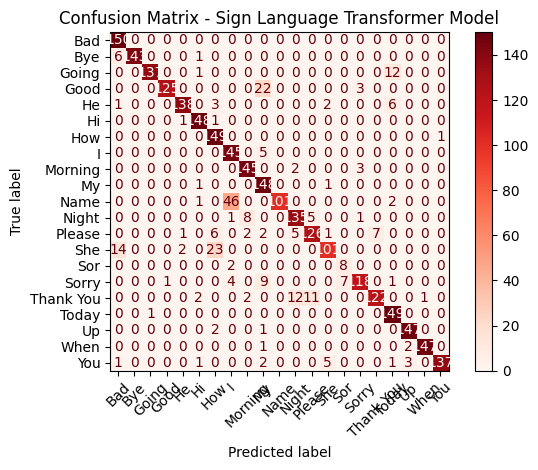

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Labels actually present in the confusion matrix
unique_labels = np.unique(np.concatenate([all_labels, all_preds]))

# Map indices to label names
plot_labels = [idx2label[i] for i in unique_labels]

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=plot_labels
)

disp.plot(
    xticks_rotation=45,
    cmap="Reds",
    colorbar=True
)

plt.title("Confusion Matrix - Sign Language Transformer Model")
plt.tight_layout()
plt.show()


In [ ]:
import os
import torch
# Corrected (file path) - use a .pth or .pt extension
MODEL_DIR = r"C:\transformer_nikhil_demo\test_new_data_model"     
SAVE_PATH = os.path.join(MODEL_DIR, "new_one_hand_model_8_dim_1024_layer_enc_6_epcohs_50.pth") # Or "model.pt"

# Ensure directory exists
os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(model.state_dict(), SAVE_PATH)

print(f"✅ Model saved at:\n{SAVE_PATH}")

✅ Model saved at:
C:\transformer_nikhil_demo\test_new_data_model\new_one_hand_model_8_dim_1024_layer_enc_6_epcohs_50.pth
